# Example: Static PSBL, BSPL, and BSBL Geometry Plots

`plot_PSBL_static`, `plot_BSPL_static`, and `plot_BSBL_static` (in
`bagle.plot_models`) draw a still-frame view of a microlensing event:

* full astrometric trajectories over a time window centered on $t_0$
* snapshot markers at $t_0$ (lens(es), unlensed source(s), lensed images)
* the light curve with a vertical line at $t_0$

The right-hand text panel lists model parameters and is titled with the
concrete class name (`type(model).__name__`).

This notebook has two parts:

1. **Keplerian orbits + parallax** — `PSBL_PhotAstrom_Par_EllOrbs_Param1`
   and `BSBL_PhotAstrom_Par_EllOrbs_Param1`.
2. **Parallax, no orbital motion** — PhotAstrom `Par` classes with a
   static companion: PSBL, BSPL, and BSBL.

The lens is at $d_L = 3000$ pc and the source at $d_S = 8$ kpc.
Parallax is present but weaker than for a nearby lens. All static
plot calls use `duration=8`
($t_E$ units) and `time_steps=500`.


In [1]:
%matplotlib inline
import numpy as np
from bagle import model
from bagle import plot_models

## PSBL with parallax and elliptical orbits

Use `PSBL_PhotAstrom_Par_EllOrbs_Param1`. The projected semi-major
axis $a = 5$ mas at $d_L = 3000$ pc is about 15 AU, so the binary lens
completes a substantial fraction of an orbit over a few Einstein
crossing times.

| Param | Value | units |
|-------|-------|-------|
| $m_{L,p}$, $m_{L,s}$ | 0.8, 0.5 | $M_\odot$ |
| $t_{0,\mathrm{com}}$ | 57000 | MJD |
| $x_{S0,E}$, $x_{S0,N}$ | 0.0, 0.0 | arcsec |
| $\beta_{\mathrm{com}}$ | 1.5 | mas |
| $\mu_{L,E}$, $\mu_{L,N}$ | 5.0, 2.0 | mas/yr |
| $\omega_{\mathrm{pri}}$, $\Omega_{\mathrm{sec}}$ | 90, 20 | deg |
| $i$, $e$ | 55, 0.35 | deg, — |
| $t_p$, $a$ | 57000, 5.0 | MJD, mas |
| $\mu_{S,E}$, $\mu_{S,N}$ | −1.0, 3.0 | mas/yr |
| $d_L$, $d_S$ | 3000, 8000 | pc |
| $b_{sff}$, mag$_S$ | 1.0, 18.0 | — |
| $\Delta m_{L_p,L_s}$ | 0.0 | mag |
| R.A., Dec. | 259.5, −29.0 | deg |


In [2]:
# Lens at 3000 pc; bulge source at 8000 pc.
mLp = 0.8
mLs = 0.5
t0_com = 57000.0
xS0_E = 0.0
xS0_N = 0.0
beta_com = 1.5
muL_E = 5.0
muL_N = 2.0
muS_E = -1.0
muS_N = 3.0
omega_pri = 90.0
big_omega_sec = 20.0
i = 55.0
e = 0.35
tp = 57000.0
a = 5.0
dL = 3000.0
dS = 8000.0
b_sff = np.array([1.0])
mag_src = np.array([18.0])
dmag_Lp_Ls = np.array([0.0])
raL = 259.5
decL = -29.0

psbl = model.PSBL_PhotAstrom_Par_EllOrbs_Param1(
    mLp, mLs, t0_com, xS0_E, xS0_N,
    beta_com, muL_E, muL_N,
    omega_pri, big_omega_sec, i, e, tp, a,
    muS_E, muS_N, dL, dS,
    b_sff, mag_src, dmag_Lp_Ls,
    raL=raL, decL=decL, root_tol=1e-8,
)

print('class:', type(psbl).__name__)
print('tE = {:.1f} days'.format(psbl.tE))
print('thetaE = {:.2f} mas'.format(psbl.thetaE_amp))
print('piE_amp = {:.2f}'.format(psbl.piE_amp))

class: PSBL_PhotAstrom_Par_EllOrbs_Param1
tE = 89.2 days
thetaE = 1.49 mas
piE_amp = 0.14


`duration` is in units of $t_E$ and is centered on $t_0$. Use
`time_steps=500` over 8 $t_E$ so the curved lens tracks and parallax
wobble are well sampled.


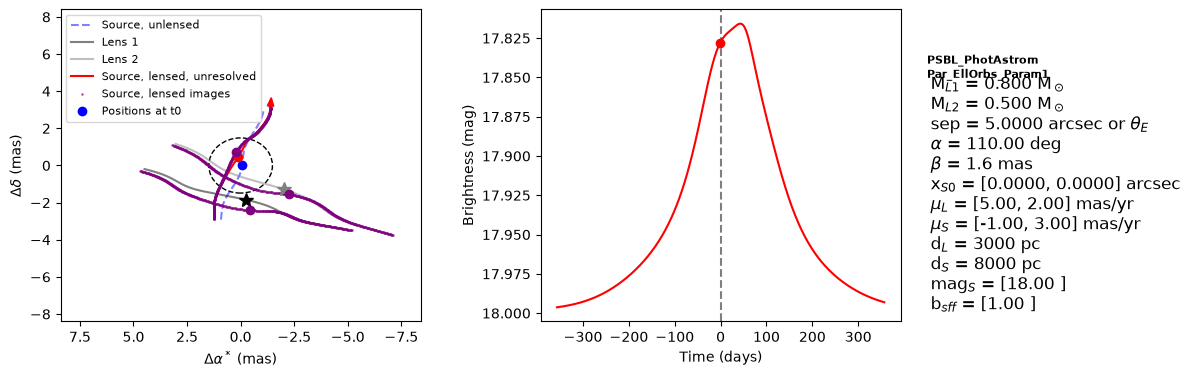

In [3]:
# Static geometry: full tracks plus t0 markers.
# The plotter always writes a PNG; the figure also displays inline.
plot_models.plot_PSBL_static(
    psbl, duration=8, time_steps=500,
    outfile='/tmp/psbl_par_ellorbs_static.png',
)

## BSBL with parallax and elliptical orbits

Use `BSBL_PhotAstrom_Par_EllOrbs_Param1`. Both the binary lens and the
binary source have Keplerian orbits. The second source and its images
are drawn in cyan / hotpink so they stay distinct from the primary.

| Param | Value | units |
|-------|-------|-------|
| $m_{L,p}$, $m_{L,s}$ | 0.8, 0.4 | $M_\odot$ |
| $t_{0,\mathrm{com}}$ | 57000 | MJD |
| $x_{S0,E}$, $x_{S0,N}$ | 0.0, 0.0 | arcsec |
| $\beta$ | 1.5 | mas |
| $\mu_{L,E}$, $\mu_{L,N}$ | 4.0, 1.0 | mas/yr |
| $\mu_{S,E}$, $\mu_{S,N}$ | −2.0, 3.0 | mas/yr |
| $d_L$, $d_S$ | 3000, 8000 | pc |
| $\omega_{L,\mathrm{pri}}$, $\Omega_{L,\mathrm{sec}}$ | 90, 20 | deg |
| $i_L$, $e_L$ | 55, 0.35 | deg, — |
| $t_{p,L}$, $a_L$ | 57000, 5.0 | MJD, mas |
| $\omega_{S,\mathrm{pri}}$, $\Omega_{S,\mathrm{sec}}$ | 0, 90 | deg |
| $i_S$, $e_S$, $P_S$ | 50, 0.25, 500 | deg, —, days |
| $t_{p,S}$, $\aleph_S$, $\aleph_{S,\mathrm{sec}}$ | 57000, 1.5, 2.0 | MJD, mas, mas |
| mag$_{S,\mathrm{pri}}$, mag$_{S,\mathrm{sec}}$ | 18.0, 19.0 | mag |
| $b_{sff}$, $\Delta m_{L_p,L_s}$ | 1.0, 20.0 | —, mag |
| R.A., Dec. | 259.5, −29.0 | deg |


In [4]:
# Lens at 3000 pc; lens and source both Keplerian.
mLp = 0.8
mLs = 0.4
t0_com = 57000.0
xS0_E = 0.0
xS0_N = 0.0
beta = 1.5
muL_E = 4.0
muL_N = 1.0
muS_E = -2.0
muS_N = 3.0
dL = 3000.0
dS = 8000.0
omegaL_pri = 90.0
big_omegaL_sec = 20.0
iL = 55.0
eL = 0.35
tpL = 57000.0
aL = 5.0
omegaS_pri = 0.0
big_omegaS_sec = 90.0
iS = 50.0
eS = 0.25
pS = 500.0
tpS = 57000.0
alephS = 1.5
aleph_secS = 2.0
mag_src_pri = 18.0
mag_src_sec = 19.0
b_sff = np.array([1.0])
dmag_Lp_Ls = np.array([20.0])
raL = 259.5
decL = -29.0

bsbl = model.BSBL_PhotAstrom_Par_EllOrbs_Param1(
    mLp, mLs, t0_com, xS0_E, xS0_N,
    beta, muL_E, muL_N, muS_E, muS_N, dL, dS,
    omegaL_pri, big_omegaL_sec, iL, eL, tpL, aL,
    omegaS_pri, big_omegaS_sec, iS, eS, pS, tpS,
    alephS, aleph_secS,
    mag_src_pri, mag_src_sec, b_sff, dmag_Lp_Ls,
    raL=raL, decL=decL, root_tol=1e-8,
)

print('class:', type(bsbl).__name__)
print('tE = {:.1f} days'.format(bsbl.tE))
print('thetaE = {:.2f} mas'.format(bsbl.thetaE_amp))
print('piE_amp = {:.2f}'.format(bsbl.piE_amp))

class: BSBL_PhotAstrom_Par_EllOrbs_Param1
tE = 82.4 days
thetaE = 1.43 mas
piE_amp = 0.15


Same time window as the PSBL example. `plot_BSBL_static` marks both
sources and both lenses at $t_0$.


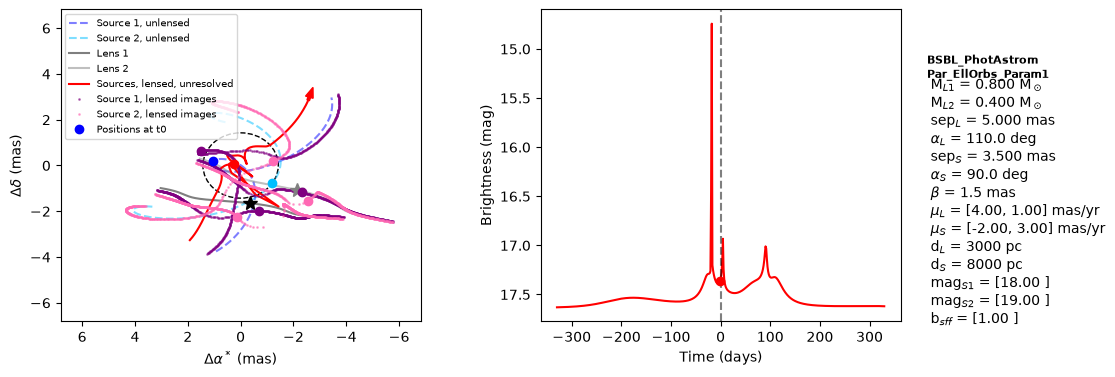

In [5]:
# Static geometry for the binary-source binary-lens event.
plot_models.plot_BSBL_static(
    bsbl, duration=8, time_steps=500,
    outfile='/tmp/bsbl_par_ellorbs_static.png',
)

## Parallax without orbital motion

The models above include Keplerian orbits. The next three examples use
PhotAstrom **Par** classes with a **static** companion (no LinOrbs,
AccOrbs, CircOrbs, or EllOrbs). Parallax is still included
($d_L = 3000$ pc, $d_S = 8$ kpc); the annual wobble is weaker than
for a nearby lens. Duration is $8\,t_E$ with `time_steps=500`,
matching the orbital examples.

`plot_PSBL_static`, `plot_BSPL_static`, and `plot_BSBL_static` mark
positions at $t_0$ and title the right-hand panel with the concrete
class name.

### PSBL with parallax, no orbits

`PSBL_PhotAstrom_Par_Param1` is a point-source binary lens with a
fixed projected separation (no orbital motion).

| Param | Value | units |
|-------|-------|-------|
| $m_{L,p}$, $m_{L,s}$ | 0.8, 0.5 | $M_\odot$ |
| $t_0$ | 57000 | MJD |
| $x_{S0,E}$, $x_{S0,N}$ | 0.0, 0.0 | arcsec |
| $\beta$ | 1.5 | mas |
| $\mu_{L,E}$, $\mu_{L,N}$ | 5.0, 2.0 | mas/yr |
| $\mu_{S,E}$, $\mu_{S,N}$ | −1.0, 3.0 | mas/yr |
| $d_L$, $d_S$ | 3000, 8000 | pc |
| sep, $\alpha$ | 5.0, 90 | mas, deg |
| $b_{sff}$, mag$_S$ | 1.0, 18.0 | — |
| $\Delta m_{L_p,L_s}$ | 0.0 | mag |
| R.A., Dec. | 259.5, −29.0 | deg |

class: PSBL_PhotAstrom_Par_Param1
tE = 89.2 days
thetaE = 1.49 mas
piE_amp = 0.14


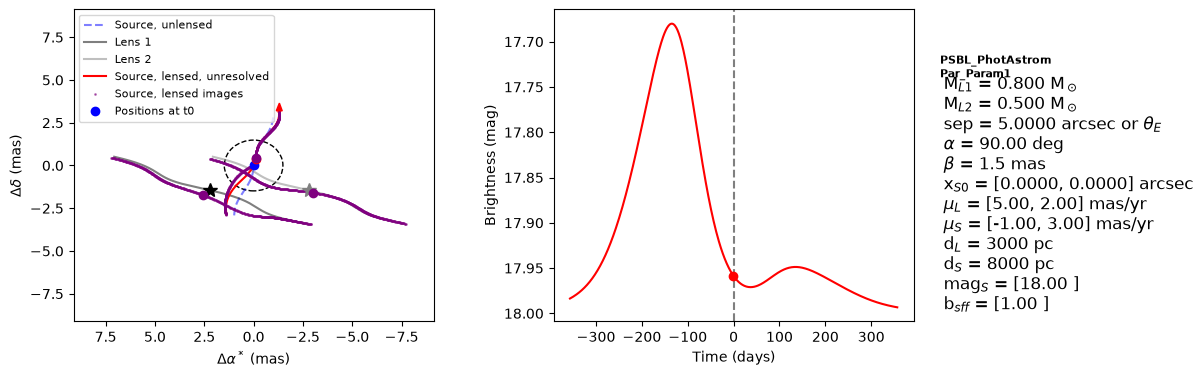

In [6]:
# Static binary lens + parallax (no orbital motion).
mLp = 0.8
mLs = 0.5
t0 = 57000.0
xS0_E = 0.0
xS0_N = 0.0
beta = 1.5
muL_E = 5.0
muL_N = 2.0
muS_E = -1.0
muS_N = 3.0
dL = 3000.0
dS = 8000.0
sep = 5.0
alpha = 90.0
b_sff = np.array([1.0])
mag_src = np.array([18.0])
dmag_Lp_Ls = np.array([0.0])
raL = 259.5
decL = -29.0

psbl_par = model.PSBL_PhotAstrom_Par_Param1(
    mLp, mLs, t0, xS0_E, xS0_N,
    beta, muL_E, muL_N, muS_E, muS_N, dL, dS,
    sep, alpha, b_sff, mag_src, dmag_Lp_Ls,
    raL=raL, decL=decL, root_tol=1e-8,
)

print('class:', type(psbl_par).__name__)
print('tE = {:.1f} days'.format(psbl_par.tE))
print('thetaE = {:.2f} mas'.format(psbl_par.thetaE_amp))
print('piE_amp = {:.2f}'.format(psbl_par.piE_amp))

plot_models.plot_PSBL_static(
    psbl_par, duration=8, time_steps=500,
    outfile='/tmp/psbl_par_static.png',
)

### BSPL with parallax, no orbits

`BSPL_PhotAstrom_Par_Param1` is a binary source and a **point** lens.
The source companion is static on the sky (fixed sep and $\alpha$).
`plot_BSPL_static` marks both sources and the single lens at $t_0$.

| Param | Value | units |
|-------|-------|-------|
| $m_L$ | 0.8 | $M_\odot$ |
| $t_0$ | 57000 | MJD |
| $\beta$ | 1.5 | mas |
| $d_L$, $d_L/d_S$ | 3000, 3000/8000 | pc, — |
| $x_{S0,E}$, $x_{S0,N}$ | 0.0, 0.0 | arcsec |
| $\mu_{L,E}$, $\mu_{L,N}$ | 5.0, 2.0 | mas/yr |
| $\mu_{S,E}$, $\mu_{S,N}$ | −1.0, 3.0 | mas/yr |
| sep, $\alpha$ | 5.0, 90 | mas, deg |
| mag$_{S,\mathrm{pri}}$, mag$_{S,\mathrm{sec}}$ | 18.0, 19.0 | mag |
| $b_{sff}$ | 1.0 | — |
| R.A., Dec. | 259.5, −29.0 | deg |

class: BSPL_PhotAstrom_Par_Param1
tE = 70.0 days
thetaE = 1.17 mas
piE_amp = 0.18


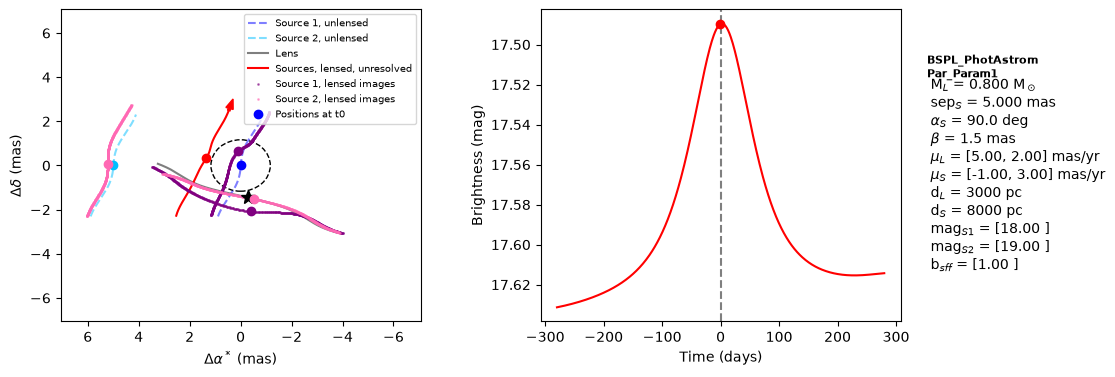

In [7]:
# Binary source, point lens + parallax (no orbital motion).
mL = 0.8
t0 = 57000.0
beta = 1.5
dL = 3000.0
dL_dS = dL / 8000.0
xS0_E = 0.0
xS0_N = 0.0
muL_E = 5.0
muL_N = 2.0
muS_E = -1.0
muS_N = 3.0
sep = 5.0
alpha = 90.0
mag_src_pri = np.array([18.0])
mag_src_sec = np.array([19.0])
b_sff = np.array([1.0])
raL = 259.5
decL = -29.0

bspl_par = model.BSPL_PhotAstrom_Par_Param1(
    mL, t0, beta, dL, dL_dS,
    xS0_E, xS0_N,
    muL_E, muL_N, muS_E, muS_N,
    sep, alpha,
    mag_src_pri, mag_src_sec, b_sff,
    raL=raL, decL=decL,
)

print('class:', type(bspl_par).__name__)
print('tE = {:.1f} days'.format(bspl_par.tE))
print('thetaE = {:.2f} mas'.format(bspl_par.thetaE_amp))
print('piE_amp = {:.2f}'.format(bspl_par.piE_amp))

plot_models.plot_BSPL_static(
    bspl_par, duration=8, time_steps=500,
    outfile='/tmp/bspl_par_static.png',
)

### BSBL with parallax, no orbits

`BSBL_PhotAstrom_Par_Param1` is a binary source and a binary lens,
both with **fixed** projected separations (no orbital motion).

| Param | Value | units |
|-------|-------|-------|
| $m_{L,p}$, $m_{L,s}$ | 0.8, 0.4 | $M_\odot$ |
| $t_0$ | 57000 | MJD |
| $x_{S0,E}$, $x_{S0,N}$ | 0.0, 0.0 | arcsec |
| $\beta$ | 1.5 | mas |
| $\mu_{L,E}$, $\mu_{L,N}$ | 4.0, 1.0 | mas/yr |
| $\mu_{S,E}$, $\mu_{S,N}$ | −2.0, 3.0 | mas/yr |
| $d_L$, $d_S$ | 3000, 8000 | pc |
| sep$_L$, $\alpha_L$ | 5.0, 90 | mas, deg |
| sep$_S$, $\alpha_S$ | 1.5, 0 | mas, deg |
| mag$_{S,\mathrm{pri}}$, mag$_{S,\mathrm{sec}}$ | 18.0, 19.0 | mag |
| $b_{sff}$, $\Delta m_{L_p,L_s}$ | 1.0, 20.0 | —, mag |
| R.A., Dec. | 259.5, −29.0 | deg |

class: BSBL_PhotAstrom_Par_Param1
tE = 82.4 days
thetaE = 1.43 mas
piE_amp = 0.15


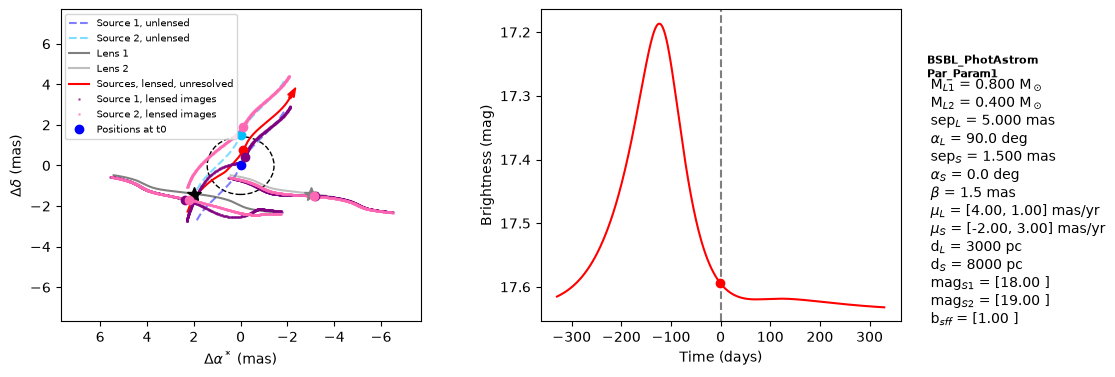

In [8]:
# Static binary source + binary lens + parallax (no orbits).
mLp = 0.8
mLs = 0.4
t0 = 57000.0
xS0_E = 0.0
xS0_N = 0.0
beta = 1.5
muL_E = 4.0
muL_N = 1.0
muS_E = -2.0
muS_N = 3.0
dL = 3000.0
dS = 8000.0
sepL = 5.0
alphaL = 90.0
sepS = 1.5
alphaS = 0.0
mag_src_pri = np.array([18.0])
mag_src_sec = np.array([19.0])
b_sff = np.array([1.0])
dmag_Lp_Ls = np.array([20.0])
raL = 259.5
decL = -29.0

bsbl_par = model.BSBL_PhotAstrom_Par_Param1(
    mLp, mLs, t0, xS0_E, xS0_N,
    beta, muL_E, muL_N, muS_E, muS_N, dL, dS,
    sepL, alphaL, sepS, alphaS,
    mag_src_pri, mag_src_sec, b_sff, dmag_Lp_Ls,
    raL=raL, decL=decL, root_tol=1e-8,
)

print('class:', type(bsbl_par).__name__)
print('tE = {:.1f} days'.format(bsbl_par.tE))
print('thetaE = {:.2f} mas'.format(bsbl_par.thetaE_amp))
print('piE_amp = {:.2f}'.format(bsbl_par.piE_amp))

plot_models.plot_BSBL_static(
    bsbl_par, duration=8, time_steps=500,
    outfile='/tmp/bsbl_par_static.png',
)